### Importing Libraries

In [49]:
%matplotlib inline
import pandas as pd
import numpy as np
import json
import sqlite3
import requests
from ydata_profiling import ProfileReport
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler ,MaxAbsScaler, RobustScaler, PowerTransformer ,FunctionTransformer,Normalizer 
from sklearn.compose import ColumnTransformer
from scipy.stats.mstats import winsorize

## Part B: Data Acquisition 

### 3. Import Datasets from multiple sources

In [3]:
# load csv files
main_transaction = pd.read_csv('data/main_transactions.csv')
main_transaction.head()

,customer_id,loan_amount,loan_purpose,transaction_count,spending_ratio,default_flag
0,CUST1000,821240.738204,Home,39,13.20,0
1,CUST1001,166721.999353,Education,18,29.43,0
2,CUST1002,371720.170500,Business,114,14.89,0
3,CUST1003,367386.291190,Car,8,9.65,0
4,CUST1004,97156.360370,Education,149,29.25,0


In [4]:
# parse the JSON file
with open('data/customer_metadata.json', 'r') as f:
    customer_metadata = json.load(f)

print(customer_metadata)

[{'customer_id': 'CUST1000', 'age': 56.0, 'gender': 'Male', 'region': 'West', 'education_level': 'Secondary', 'employment_type': 'Salaried', 'join_date': '2021-05-24'}, {'customer_id': 'CUST1001', 'age': 69.0, 'gender': 'Male', 'region': 'North', 'education_level': 'Graduate', 'employment_type': 'Self-Employed', 'join_date': '2021-10-23'}, {'customer_id': 'CUST1002', 'age': 46.0, 'gender': 'Other', 'region': 'North', 'education_level': 'Graduate', 'employment_type': 'Salaried', 'join_date': '2018-04-27'}, {'customer_id': 'CUST1003', 'age': 32.0, 'gender': 'Female', 'region': 'North', 'education_level': 'Graduate', 'employment_type': 'Salaried', 'join_date': '2021-04-17'}, {'customer_id': 'CUST1004', 'age': nan, 'gender': 'Male', 'region': 'North', 'education_level': 'Post-Graduate', 'employment_type': 'Salaried', 'join_date': '2021-06-23'}, {'customer_id': 'CUST1005', 'age': 25.0, 'gender': 'Female', 'region': 'West', 'education_level': 'Secondary', 'employment_type': 'Self-Employed', 

In [5]:
# fetch recorrds from sql
conn = sqlite3.connect("data/repayment_history.db")
repayment_data = pd.read_sql("SELECT * FROM repayment_data", conn)
print(repayment_data.head())

  customer_id  annual_income  credit_score  repayment_history
0    CUST1000  841473.298565    663.935111                  3
1    CUST1001  179168.069828    714.909764                  2
2    CUST1002            NaN    635.226534                  1
3    CUST1003  311056.808239    582.369296                  0
4    CUST1004            NaN    554.746159                  3


In [6]:
# fetch data from the API (external economic indicators)
# response = requests.get("https://bytebin.lucko.me/0W2HQJlJKr")
# economic_data = response.json()
# print(economic_data)

In [7]:
# load main dataset
df=pd.read_csv('data/data.csv')
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST1000,56.0,Male,West,Secondary,Salaried,841473.298565,821240.738204,Home,663.935111,3,39,13.20,2021-05-24,0
1,CUST1001,69.0,Male,North,Graduate,Self-Employed,179168.069828,166721.999353,Education,714.909764,2,18,29.43,2021-10-23,0
2,CUST1002,46.0,Other,North,Graduate,Salaried,NaN,371720.170500,Business,635.226534,1,114,14.89,2018-04-27,0
3,CUST1003,32.0,Female,North,Graduate,Salaried,311056.808239,367386.291190,Car,582.369296,0,8,9.65,2021-04-17,0
4,CUST1004,NaN,Male,North,Post-Graduate,Salaried,NaN,97156.360370,Education,554.746159,3,149,29.25,2021-06-23,0


In [8]:
numeric_columns =['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history','transaction_count', 'spending_ratio']

## Part C: Data Understanding & Cleaning

### 4. Explore the dataset using pandas

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   object 
 1   age                922 non-null    float64
 2   gender             953 non-null    object 
 3   region             1000 non-null   object 
 4   education_level    1000 non-null   object 
 5   employment_type    937 non-null    object 
 6   annual_income      917 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   object 
 9   credit_score       888 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   object 
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 117.3+ KB


In [10]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,922.000000,9.170000e+02,1.000000e+03,888.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.786334,1.790538e+06,4.350655e+05,675.989490,1.267000,91.892000,18.042440,0.037000
std,14.982614,1.095508e+07,1.724177e+06,84.108116,1.118464,50.098925,9.263572,0.188856
min,18.000000,8.689297e+04,2.061440e+04,150.000000,0.000000,5.000000,4.190000,0.000000
25%,31.000000,2.877050e+05,9.754397e+04,625.212264,0.000000,48.000000,11.275000,0.000000
50%,44.000000,4.363368e+05,1.990802e+05,678.550946,1.000000,91.000000,16.220000,0.000000
75%,56.000000,7.011574e+05,3.838792e+05,727.871943,2.000000,136.000000,22.352500,0.000000
max,69.000000,1.372205e+08,2.401228e+07,990.000000,6.000000,179.000000,82.110000,1.000000


### 5. Perform Pandas Profiling to generate a data quality report

In [11]:

# profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
# profile.to_file("report/data_quality_report.html")

### 6. Handling Missing data with:

#### 6.1 Simple Imputer (numerical)

In [12]:
df_copy = df.copy()
print(f'before imputation, missing values in age column: {df_copy["age"].isnull().sum()}')
age_imputer = SimpleImputer(strategy='mean')
df_copy['age'] = age_imputer.fit_transform(df_copy[['age']])
print(f'after imputation, missing values in age column: {df_copy["age"].isnull().sum()}')

before imputation, missing values in age column: 78
after imputation, missing values in age column: 0


#### 6.2 Simple Imputer (categorical)

In [13]:
print(f'before imputation, missing values in employment_type column: {df["employment_type"].isnull().sum()}')
employment_imputer = SimpleImputer(strategy='most_frequent')
df['employment_type'] = employment_imputer.fit_transform(df[['employment_type']]).ravel()
print(f'after imputation, missing values in employment_type column: {df["employment_type"].isnull().sum()}')

before imputation, missing values in employment_type column: 63
after imputation, missing values in employment_type column: 0


#### 6.3 Most Frequent Categorical Imputer

In [14]:
print(f'before imputation, missing values in gender column: {df["gender"].isnull().sum()}')
gender_imputer = SimpleImputer(strategy='most_frequent')
df['gender'] = gender_imputer.fit_transform(df[['gender']]).ravel()
print(f'after imputation, missing values in gender column: {df["gender"].isnull().sum()}')

before imputation, missing values in gender column: 47
after imputation, missing values in gender column: 0


#### 6.4 Missing Indicator + Random Sample Imputation

In [15]:
df_sample=df.copy()
print(f'before imputation, missing values in annual_income column: {df_sample["annual_income"].isnull().sum()}')
df_sample['annual_income_missing_ind'] = df_sample['annual_income'].isnull().astype(int)

null_count = df_sample['annual_income'].isnull().sum()
random_values = df_sample['annual_income'].dropna().sample(
    n=null_count, 
    random_state=42,
    replace=True).values

df_sample.loc[df_sample['annual_income'].isnull(), 'annual_income'] = random_values
print(f'after imputation, missing values in annual_income column: {df_sample["annual_income"].isnull().sum()}')
df_sample[['annual_income', 'annual_income_missing_ind']].head()

before imputation, missing values in annual_income column: 83
after imputation, missing values in annual_income column: 0


,annual_income,annual_income_missing_ind
0,841473.298565,0
1,179168.069828,0
2,454201.985323,1
3,311056.808239,0
4,378954.979964,1


#### 6.5 KNN Imputer

In [16]:
df_knn = df.copy()
print(f'before imputation, missing values in numeric columns:\n{df_knn[numeric_columns].isnull().sum()}')
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[numeric_columns] = knn_imputer.fit_transform(df_knn[numeric_columns])
print(f'after imputation, missing values in numeric columns:\n{df_knn[numeric_columns].isnull().sum()}')

before imputation, missing values in numeric columns:
age                   78
annual_income         83
loan_amount            0
credit_score         112
repayment_history      0
transaction_count      0
spending_ratio         0
dtype: int64
after imputation, missing values in numeric columns:
age                  0
annual_income        0
loan_amount          0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
dtype: int64


#### 6.6 MICE Algorithm

In [17]:
print(f'before imputation, missing values in numeric columns:\n{df[numeric_columns].isnull().sum()}')
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
df[numeric_columns] = iterative_imputer.fit_transform(df[numeric_columns])
print(f'after imputation, missing values in numeric columns:\n{df[numeric_columns].isnull().sum()}')

before imputation, missing values in numeric columns:
age                   78
annual_income         83
loan_amount            0
credit_score         112
repayment_history      0
transaction_count      0
spending_ratio         0
dtype: int64
after imputation, missing values in numeric columns:
age                  0
annual_income        0
loan_amount          0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
dtype: int64


#### 6.7 Complete Case Analysis (dropping rows/columns)

## Part D: Outlier Handling

### 7. Detect and treat outliers using:

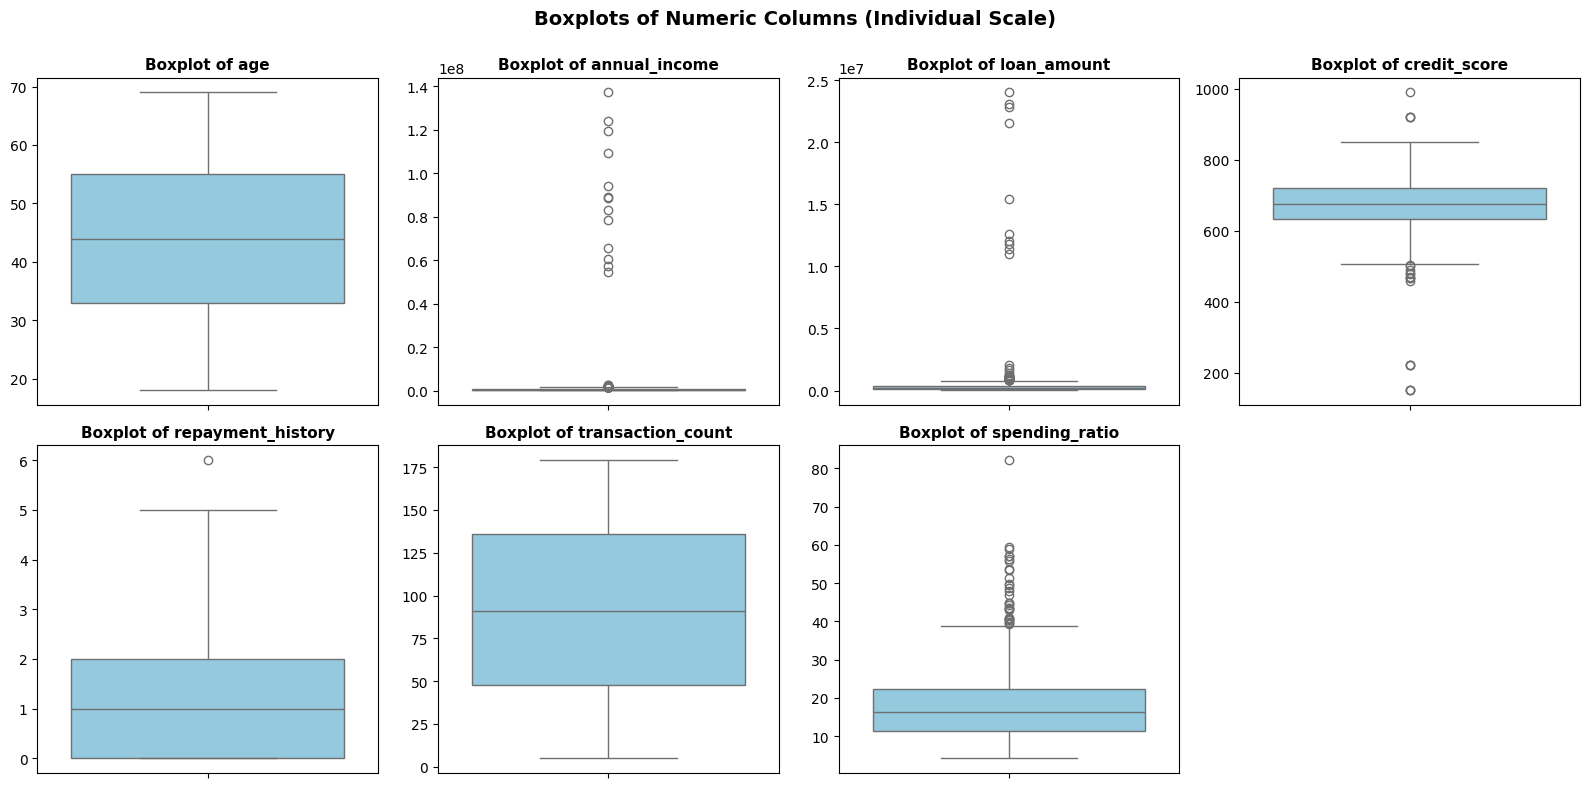

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2x4 Subplot Grid for all numerical columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

# Extra blank subplots remove karva mate
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numeric Columns (Individual Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### 7.1 Z-Score Method

In [19]:
df_copy=df.copy()
mean = df['credit_score'].mean()
std = df['credit_score'].std()
z_score = np.abs((df['credit_score'] - mean) / std )
print(f'shape of dataset before removing outliers: {df_copy.shape}')
df = df[z_score < 3]
print(f'shape of dataset after removing outliers: {df.shape}')

shape of dataset before removing outliers: (1000, 15)
shape of dataset after removing outliers: (990, 15)


#### 7.2 IQR Method

In [20]:

q3 = df['annual_income'].quantile(0.75)
q1 = df['annual_income'].quantile(0.25)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df['annual_income'] = df['annual_income'].clip(lower=lower_bound, upper=upper_bound)

#### 7.3 Percentile Method

In [21]:
lower_percentile = df['loan_amount'].quantile(0.01)
upper_percentile = df['loan_amount'].quantile(0.99)

df['loan_amount'] = df['loan_amount'].clip(lower=lower_percentile, upper=upper_percentile)

#### 7.4 Winsorization Method

In [22]:
df['spending_ratio'] = winsorize(df['spending_ratio'], limits=[0.01, 0.01])

### Before and After Outlier Treatment Visualization

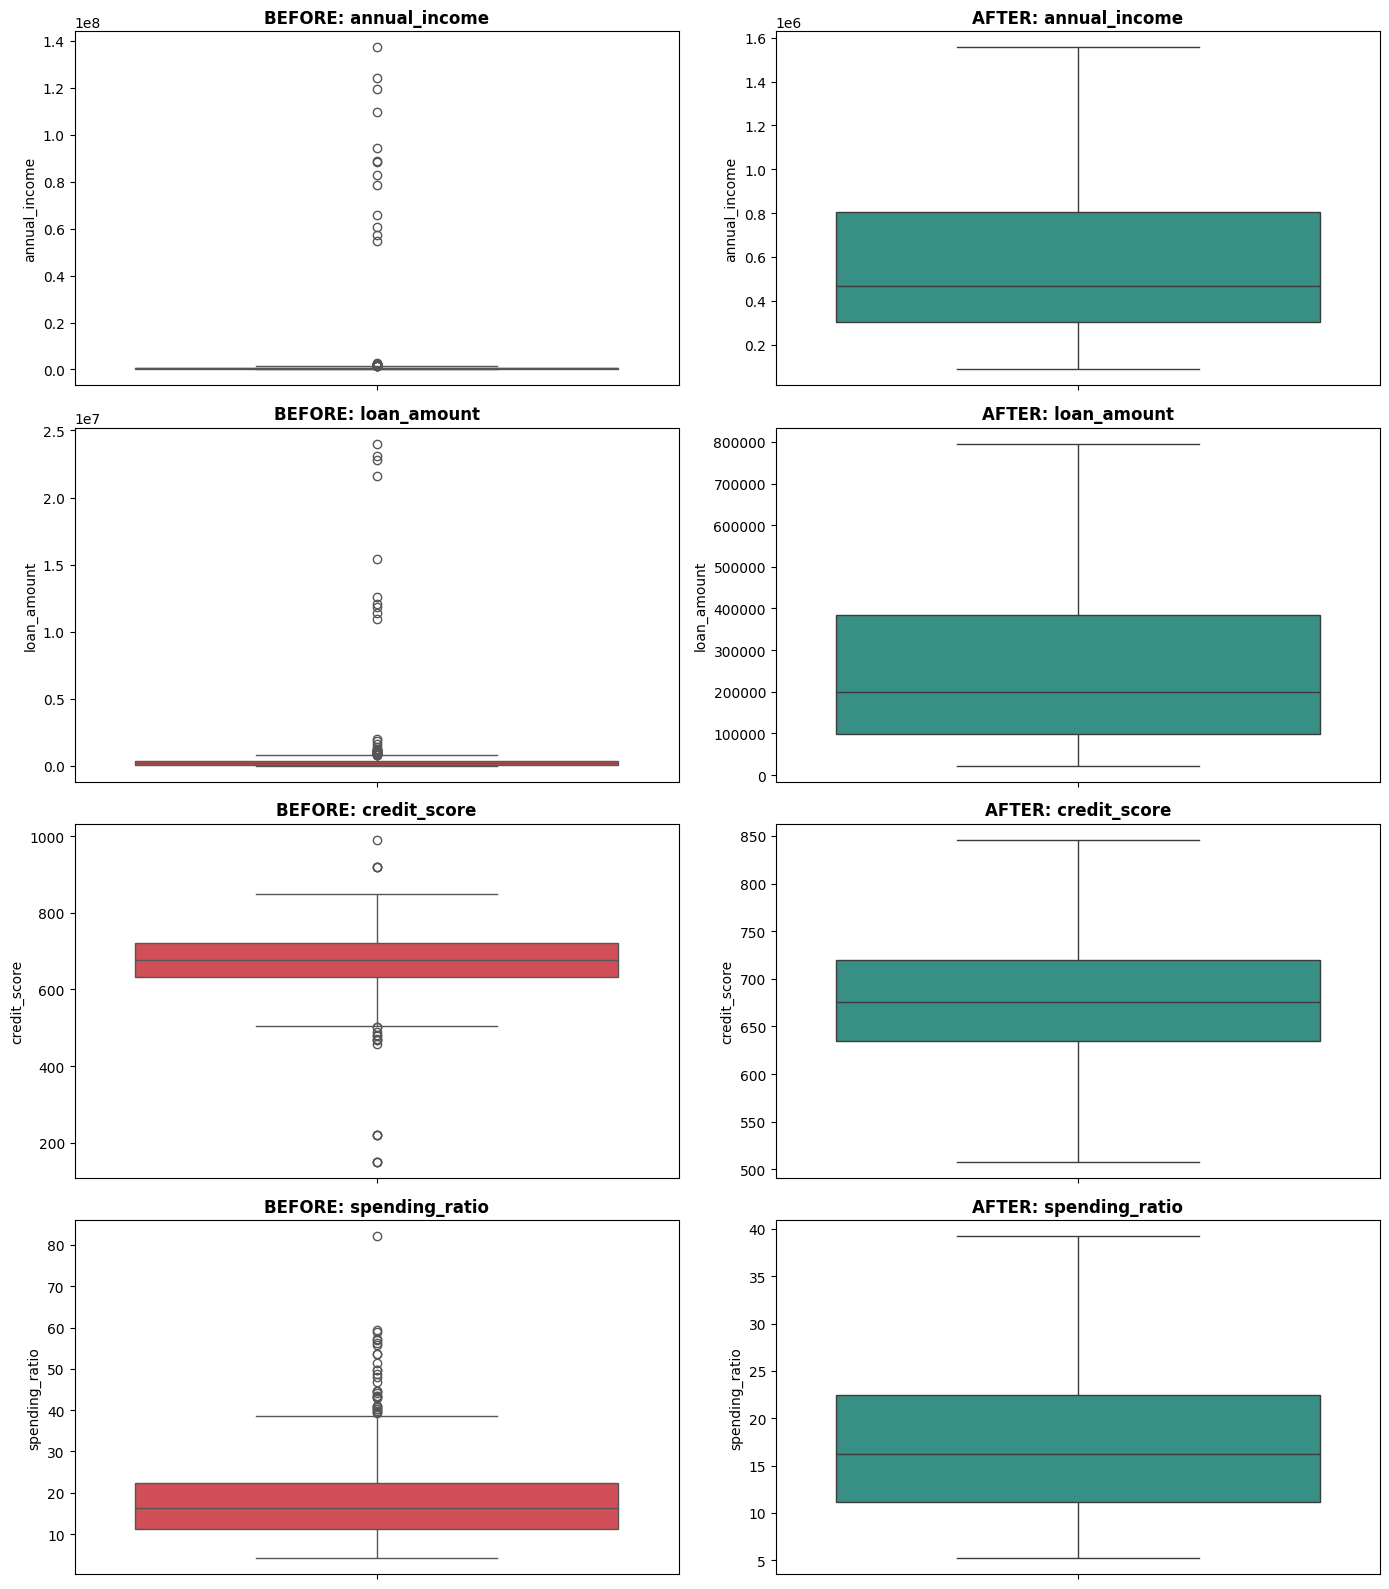

In [23]:
main_cols = ['annual_income', 'loan_amount', 'credit_score', 'spending_ratio']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, col in enumerate(main_cols):
    
    sns.boxplot(y=df_copy[col], ax=axes[i, 0], color='#e63946')
    axes[i, 0].set_title(f'BEFORE: {col}', fontsize=12, fontweight='bold',)
    
    sns.boxplot(y=df[col], ax=axes[i, 1], color='#2a9d8f',showfliers=False)
    axes[i, 1].set_title(f'AFTER: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Part E: Feature Engineering

### 8. Handle Variable types:

#### 8.1 Mixed Variables (numerical and categorical)

In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['age', 'annual_income', 'loan_amount', 'credit_score',
       'repayment_history', 'transaction_count', 'spending_ratio',
       'default_flag'],
      dtype='object')
Categorical: Index(['customer_id', 'gender', 'region', 'education_level', 'employment_type',
       'loan_purpose', 'join_date'],
      dtype='object')


#### 8.2 Date & Time variables -> extract year , month, day, weekady

In [25]:
df['join_date'] = pd.to_datetime(df['join_date'],errors='coerce')
df['join_year'] = df['join_date'].dt.year
df['join_month'] = df['join_date'].dt.month
df['join_day'] = df['join_date'].dt.day
df['join_weekday'] = df['join_date'].dt.weekday

df[['join_date', 'join_year', 'join_month', 'join_day', 'join_weekday']].head()

,join_date,join_year,join_month,join_day,join_weekday
0,2021-05-24,2021,5,24,0
1,2021-10-23,2021,10,23,5
2,2018-04-27,2018,4,27,4
3,2021-04-17,2021,4,17,5
4,2021-06-23,2021,6,23,2


### 9. Encoding categorical variables:

#### 9.1 Ordinal Encoding (education levels)

In [26]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, KBinsDiscretizer, Binarizer, QuantileTransformer

education_encoder=OrdinalEncoder(categories=[df['education_level'].unique()])
df['education_level_encoded'] = education_encoder.fit_transform(df[['education_level']])
df[['education_level', 'education_level_encoded']].head()

,education_level,education_level_encoded
0,Secondary,0.0
1,Graduate,1.0
2,Graduate,1.0
3,Graduate,1.0
4,Post-Graduate,2.0


#### 9.2 Label Encoding (binary features)

In [27]:
gender_encoder=LabelEncoder()
df['gender_encoded'] = gender_encoder.fit_transform(df['gender'])
df[['gender', 'gender_encoded']].head()

,gender,gender_encoded
0,Male,1
1,Male,1
2,Other,2
3,Female,0
4,Male,1


#### 9.3 One Hot Encoding (regions , loan purpose)

In [28]:
region_encoder=pd.get_dummies(df['region'], prefix='region', drop_first=True)
df=pd.concat([df, region_encoder], axis=1)
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,default_flag,join_year,join_month,join_day,join_weekday,education_level_encoded,gender_encoded,region_North,region_South,region_West
0,CUST1000,56.00000,Male,West,Secondary,Salaried,8.414733e+05,821240.738204,Home,663.935111,...,0,2021,5,24,0,0.0,1,False,False,True
1,CUST1001,69.00000,Male,North,Graduate,Self-Employed,1.791681e+05,166721.999353,Education,714.909764,...,0,2021,10,23,5,1.0,1,True,False,False
2,CUST1002,46.00000,Other,North,Graduate,Salaried,1.556425e+06,371720.170500,Business,635.226534,...,0,2018,4,27,4,1.0,2,True,False,False
3,CUST1003,32.00000,Female,North,Graduate,Salaried,3.110568e+05,367386.291190,Car,582.369296,...,0,2021,4,17,5,1.0,0,True,False,False
4,CUST1004,43.86664,Male,North,Post-Graduate,Salaried,1.556425e+06,97156.360370,Education,554.746159,...,0,2021,6,23,2,2.0,1,True,False,False


In [29]:
ohe=OneHotEncoder(sparse_output=False, drop='first')
loan_purpose_encoded=ohe.fit_transform(df[['loan_purpose']])
feature_names=ohe.get_feature_names_out(['loan_purpose'])
loan_purpose_encoded_df=pd.DataFrame(loan_purpose_encoded, columns=feature_names , index=df.index)
df=pd.concat([df, loan_purpose_encoded_df], axis=1)
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,...,join_weekday,education_level_encoded,gender_encoded,region_North,region_South,region_West,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,CUST1000,56.00000,Male,West,Secondary,Salaried,8.414733e+05,821240.738204,Home,663.935111,...,0,0.0,1,False,False,True,0.0,0.0,1.0,0.0
1,CUST1001,69.00000,Male,North,Graduate,Self-Employed,1.791681e+05,166721.999353,Education,714.909764,...,5,1.0,1,True,False,False,0.0,1.0,0.0,0.0
2,CUST1002,46.00000,Other,North,Graduate,Salaried,1.556425e+06,371720.170500,Business,635.226534,...,4,1.0,2,True,False,False,0.0,0.0,0.0,0.0
3,CUST1003,32.00000,Female,North,Graduate,Salaried,3.110568e+05,367386.291190,Car,582.369296,...,5,1.0,0,True,False,False,1.0,0.0,0.0,0.0
4,CUST1004,43.86664,Male,North,Post-Graduate,Salaried,1.556425e+06,97156.360370,Education,554.746159,...,2,2.0,1,True,False,False,0.0,1.0,0.0,0.0


### 10. Encoding numerical features:

#### 10.1 Binning (discretize income into groups)

In [30]:
df['annual_income_binned']=pd.cut(df['annual_income'], bins=3, labels=['Low', 'Medium', 'High'])
df[['annual_income','annual_income_binned']].head()

,annual_income,annual_income_binned
0,8.414733e+05,Medium
1,1.791681e+05,Low
2,1.556425e+06,High
3,3.110568e+05,Low
4,1.556425e+06,High


In [31]:
df['repayment_history_binned']=pd.cut(df['repayment_history'], bins=3, labels=['Low', 'Medium', 'High'])
df[['repayment_history','repayment_history_binned']].head()

,repayment_history,repayment_history_binned
0,3.0,Medium
1,2.0,Low
2,1.0,Low
3,0.0,Low
4,3.0,Medium


#### 10.2 Binarization (flag if > threshold)

In [32]:
credit_score_bin=Binarizer(threshold=700)
df['credit_score_binarized']=credit_score_bin.fit_transform(df[['credit_score']])
df[['credit_score','credit_score_binarized']].head()

,credit_score,credit_score_binarized
0,663.935111,0.0
1,714.909764,1.0
2,635.226534,0.0
3,582.369296,0.0
4,554.746159,0.0


#### 10.3 Quantile Binning

In [33]:
df['transaction_count_quantile_binned']=pd.qcut(df['transaction_count'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df[['transaction_count', 'transaction_count_quantile_binned']].head()

C:\Users\ansh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,transaction_count,transaction_count_quantile_binned
0,39.0,Low
1,18.0,Low
2,114.0,High
3,8.0,Low
4,149.0,Very High


#### 10.4 KMeans Binning

In [34]:
transaction_count_bin=KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')
df['transaction_count_kmeans_binned']=transaction_count_bin.fit_transform(df[['transaction_count']])
df[['transaction_count', 'transaction_count_quantile_binned', 'transaction_count_kmeans_binned']].head()

,transaction_count,transaction_count_quantile_binned,transaction_count_kmeans_binned
0,39.0,Low,0.0
1,18.0,Low,0.0
2,114.0,High,2.0
3,8.0,Low,0.0
4,149.0,Very High,3.0


## Part F: Feature Scaling

### 11. Apply multiple scaling methods:

#### 11.1 Standization (Z-score scaling)

In [35]:

scaler = StandardScaler()
df_std = pd.DataFrame(scaler.fit_transform(df[['annual_income','loan_amount']]), columns=['annual_income', 'loan_amount'], index=df.index)
df_std

,annual_income,loan_amount
0,0.502069,1.430529
1,-1.027332,-0.366592
2,2.153041,0.196275
3,-0.722773,0.184375
4,2.153041,-0.557599
...,...,...
995,-1.055833,1.045692
996,-0.709579,0.889192
997,-0.399240,0.093833
998,2.153041,0.713282


#### 11.2 Normalization

In [36]:
norm_l2 = Normalizer(norm='l2')
df_norm = pd.DataFrame(norm_l2.fit_transform(df[numeric_columns]), columns=numeric_columns, index=df.index)
df_norm.head()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.000048,0.715658,0.698451,0.000565,2.551447e-06,0.000033,0.000011
1,0.000282,0.732073,0.681219,0.002921,8.171919e-06,0.000074,0.000120
2,0.000029,0.972645,0.232296,0.000397,6.249225e-07,0.000071,0.000009
3,0.000066,0.646174,0.763190,0.001210,0.000000e+00,0.000017,0.000020
4,0.000028,0.998057,0.062302,0.000356,1.923750e-06,0.000096,0.000019


#### 11.3 Min-Max Scaling


In [37]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[numeric_columns]), columns=numeric_columns, index=df.index)
df_minmax.head()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.745098,0.513483,0.267145,0.525626,0.500000,0.195402,0.172294
1,1.000000,0.062792,0.048150,0.655586,0.333333,0.074713,0.523593
2,0.549020,1.000000,0.116740,0.452433,0.166667,0.626437,0.208874
3,0.274510,0.152541,0.115290,0.317673,0.000000,0.017241,0.095455
4,0.507189,1.000000,0.024874,0.247248,0.500000,0.827586,0.519697


#### 11.4 MaxAbs Scaling

In [38]:
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df[numeric_columns]), columns=numeric_columns, index=df.index)
df_maxabs.head()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.811594,0.540645,0.272697,0.781100,0.500000,0.217877,0.256610
1,1.000000,0.115115,0.055361,0.841070,0.333333,0.100559,0.572123
2,0.666667,1.000000,0.123431,0.747325,0.166667,0.636872,0.289463
3,0.463768,0.199853,0.121992,0.685140,0.000000,0.044693,0.187597
4,0.635748,1.000000,0.032261,0.652643,0.500000,0.832402,0.568624


#### 11.5 Robust Scaling

In [39]:
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(robust_scaler.fit_transform(df[numeric_columns]), columns=numeric_columns, index=df.index)
df_robust.head()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.546355,0.746150,2.172627,-0.142576,1.0,-0.590909,-0.272018
1,1.137264,-0.575568,-0.112997,0.456836,0.5,-0.829545,1.175474
2,0.091810,2.172930,0.602870,-0.480160,0.0,0.261364,-0.121293
3,-0.544554,-0.312366,0.587736,-1.101709,-0.5,-0.943182,-0.588629
4,-0.005161,2.172930,-0.355925,-1.426529,1.0,0.659091,1.159420


## Part G: Feature Construction & Transformation

### 12. Apply transformations:

#### 12.1 Function Transformer (log, sqrt, reciprocal)

In [40]:
log_transformer=FunctionTransformer(np.log1p, validate=True)
df['spending_ratio_log_transformed']=log_transformer.fit_transform(df[['spending_ratio']])

sqrt_transformer=FunctionTransformer(np.sqrt, validate=True)
df['spending_ratio_sqrt_transformed']=sqrt_transformer.fit_transform(df[['spending_ratio']])

def reciprocal(x):
  return 1/(x+1)
reciprocal_transformer=FunctionTransformer(reciprocal, validate=True)
df['spending_ratio_reciprocal_transformed']=reciprocal_transformer.fit_transform(df[['spending_ratio']])

df[['spending_ratio', 'spending_ratio_log_transformed', 'spending_ratio_sqrt_transformed', 'spending_ratio_reciprocal_transformed']].head()

,spending_ratio,spending_ratio_log_transformed,spending_ratio_sqrt_transformed,spending_ratio_reciprocal_transformed
0,13.20,2.653242,3.633180,0.070423
1,29.43,3.415429,5.424942,0.032862
2,14.89,2.765690,3.858756,0.062933
3,9.65,2.365560,3.106445,0.093897
4,29.25,3.409496,5.408327,0.033058


#### 12.2 Power Transformer (Yeo-Johnson, Box-Cox) 

In [41]:
pt_box=PowerTransformer(method='box-cox')
df['loan-amount_boxcox_transformed']=pt_box.fit_transform(df[['loan_amount']])
df[['loan_amount', 'loan-amount_boxcox_transformed']].head()

,loan_amount,loan-amount_boxcox_transformed
0,821240.738204,1.529132
1,166721.999353,-0.152502
2,371720.170500,0.680408
3,367386.291190,0.668042
4,97156.360370,-0.699329


In [42]:
pt_yeo=PowerTransformer(method='yeo-johnson')
df['annual_income_yeojohnson_transformed']=pt_yeo.fit_transform(df[['annual_income']])
df[['annual_income', 'annual_income_yeojohnson_transformed']].head()

,annual_income,annual_income_yeojohnson_transformed
0,8.414733e+05,0.780404
1,1.791681e+05,-1.516108
2,1.556425e+06,1.652953
3,3.110568e+05,-0.679992
4,1.556425e+06,1.652953


#### 12.3 Column Transformer (apply different preprocessing steps| to different columns)

In [50]:
ct=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['annual_income', 'loan_amount']),
        ('cat', OneHotEncoder(drop='first'), ['employment_type', 'gender', 'region', 'loan_purpose'])
    ]
)
pd.DataFrame(ct.fit_transform(df), columns=['annual_income_scaled', 'loan_amount_scaled'] + list(ct.named_transformers_['cat'].get_feature_names_out(['employment_type', 'gender', 'region', 'loan_purpose'])), index=df.index).head()

,annual_income_scaled,loan_amount_scaled,employment_type_Self-Employed,employment_type_Unemployed,gender_Male,gender_Other,region_North,region_South,region_West,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,0.502069,1.430529,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.027332,-0.366592,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.153041,0.196275,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.722773,0.184375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2.153041,-0.557599,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### 13. Construct new features:

#### 13.1 Debt-to-Income Ratio

In [43]:
df['debt_to_income_ratio']=df['loan_amount']/df['annual_income']
df[['loan_amount', 'annual_income', 'debt_to_income_ratio']].head()

,loan_amount,annual_income,debt_to_income_ratio
0,821240.738204,8.414733e+05,0.975956
1,166721.999353,1.791681e+05,0.930534
2,371720.170500,1.556425e+06,0.238829
3,367386.291190,3.110568e+05,1.181091
4,97156.360370,1.556425e+06,0.062423


#### 13.2 Average monthly transactions:

In [44]:
df['avg_monthly_transactions'] = df['transaction_count'] / 12
df[['transaction_count', 'avg_monthly_transactions']].head()

,transaction_count,avg_monthly_transactions
0,39.0,3.250000
1,18.0,1.500000
2,114.0,9.500000
3,8.0,0.666667
4,149.0,12.416667


#### 13.3 Spending-to-Income Ratio

In [45]:
df['spending_to_income_ratio'] = df['spending_ratio'] / df['annual_income']
df[['spending_ratio', 'annual_income', 'spending_to_income_ratio']].head()

,spending_ratio,annual_income,spending_to_income_ratio
0,13.20,8.414733e+05,0.000016
1,29.43,1.791681e+05,0.000164
2,14.89,1.556425e+06,0.000010
3,9.65,3.110568e+05,0.000031
4,29.25,1.556425e+06,0.000019
